# QTL MaxCut with Parameter-Shift and Exact Comparison

This notebook keeps the original `tilted_loss_momentum.ipynb` unchanged and provides a separate experiment branch with three changes:

- parameter-shift gradients instead of SPSA
- weaker gamma-dependent learning-rate penalty
- a small exact-vs-sampled comparison

In [121]:
from __future__ import annotations

import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pennylane as qml
from IPython.display import display
from pennylane import numpy as qnp


@dataclass(frozen=True)
class ObjectiveSpec:
    name: str
    kind: str
    alpha: float | None = None
    gamma: float | None = None
    gamma_start: float | None = None
    gamma_end: float | None = None
    schedule: str | None = None
    color: str = "C0"


PARAMSHIFT_OBJECTIVES = [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("CVaR 0.2", "cvar", alpha=0.2, color="#ff7f0e"),
    ObjectiveSpec("QTL gamma=2.0", "qtl", gamma=2.0, color="#2ca02c"),
    ObjectiveSpec("QTL gamma=5.0", "qtl", gamma=5.0, color="#8c564b"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0.0,
        gamma_end=5.0,
        schedule="linear",
        color="#9467bd",
    ),
]

QUICK_CONFIG = {
    "graph_families": ["erdos_renyi"],
    "sizes": [8],
    "depths": [2],
    "seeds": [0],
    "steps": 150,
    "shots": 512,
    "lr": 0.18,
    "lr_decay_power": 0.55,
    "lr_decay_offset": 6.0,
    "beta_mom": 0.7,
    "gamma_lr_penalty": 0.02,
    "grad_clip": 2.5,
}

FULL_CONFIG = {
    **QUICK_CONFIG,
    "sizes": [14],
    "depths": [3],
    "seeds": [0, 1, 2],
    "steps": 150,
    "shots": 4096,
}

BENCHMARK_CONFIG = QUICK_CONFIG

EXACT_SMALL_SCALE_CONFIG = {
    **QUICK_CONFIG,
    "sizes": [6],
    "depths": [1],
    "seeds": [0],
    "steps": 150,
    "shots": 256,
}

TARGET_RATIO = 0.99
CURVE_METRIC = "mean_ratio"
CURVE_METRIC_LABEL = "Mean cut ratio"
GAIN_METRIC = "final_mean_ratio"

OBJECTIVE_COLORS = {obj.name: obj.color for obj in PARAMSHIFT_OBJECTIVES}
CURVE_OBJECTIVES = [obj.name for obj in PARAMSHIFT_OBJECTIVES]

plt.style.use("seaborn-v0_8-whitegrid")

print("Target ratio:", TARGET_RATIO)
print("Benchmark config:", BENCHMARK_CONFIG)
print("Exact comparison config:", EXACT_SMALL_SCALE_CONFIG)
print("Full config available for longer runs:", FULL_CONFIG)

Target ratio: 0.99
Benchmark config: {'graph_families': ['erdos_renyi'], 'sizes': [8], 'depths': [2], 'seeds': [0], 'steps': 150, 'shots': 512, 'lr': 0.18, 'lr_decay_power': 0.55, 'lr_decay_offset': 6.0, 'beta_mom': 0.7, 'gamma_lr_penalty': 0.02, 'grad_clip': 2.5}
Exact comparison config: {'graph_families': ['erdos_renyi'], 'sizes': [6], 'depths': [1], 'seeds': [0], 'steps': 150, 'shots': 256, 'lr': 0.18, 'lr_decay_power': 0.55, 'lr_decay_offset': 6.0, 'beta_mom': 0.7, 'gamma_lr_penalty': 0.02, 'grad_clip': 2.5}
Full config available for longer runs: {'graph_families': ['erdos_renyi'], 'sizes': [14], 'depths': [3], 'seeds': [0, 1, 2], 'steps': 150, 'shots': 4096, 'lr': 0.18, 'lr_decay_power': 0.55, 'lr_decay_offset': 6.0, 'beta_mom': 0.7, 'gamma_lr_penalty': 0.02, 'grad_clip': 2.5}


In [122]:
def make_graph(n: int, family: str, seed: int) -> nx.Graph:
    if family == "regular3":
        graph = nx.random_regular_graph(3, n, seed=seed)
    elif family == "erdos_renyi":
        edge_prob = min(0.45, 3.0 / (n - 1))
        graph = nx.gnp_random_graph(n, edge_prob, seed=seed)
        while not nx.is_connected(graph):
            seed += 1
            graph = nx.gnp_random_graph(n, edge_prob, seed=seed)
    else:
        raise ValueError(f"Unknown graph family: {family}")
    return graph


def basis_states(n: int) -> np.ndarray:
    return np.array([list(map(int, f"{i:0{n}b}")) for i in range(2**n)], dtype=int)


def cut_values_from_samples(samples: np.ndarray, edges: list[tuple[int, int]]) -> np.ndarray:
    samples = np.asarray(samples, dtype=int)
    cuts = np.zeros(samples.shape[0], dtype=int)
    for u, v in edges:
        cuts += (samples[:, u] != samples[:, v]).astype(int)
    return cuts


def exact_cut_data(n: int, edges: list[tuple[int, int]]) -> tuple[np.ndarray, np.ndarray, float]:
    basis = basis_states(n)
    cuts = cut_values_from_samples(basis, edges)
    return basis, cuts.astype(float), float(cuts.max())


def qtl_loss_from_distribution(probs, losses, gamma):
    probs = qml.math.asarray(probs)
    losses = qml.math.asarray(losses)
    if gamma is None or abs(gamma) < 1e-12:
        return qml.math.dot(probs, losses)
    loss_min = qml.math.min(losses)
    shifted = losses - loss_min
    weighted = qml.math.sum(probs * qml.math.exp(-gamma * shifted))
    return loss_min - qml.math.log(weighted) / gamma


def cvar_loss_from_distribution(probs, losses, alpha):
    if alpha is None or not (0.0 < alpha <= 1.0):
        raise ValueError("CVaR alpha must lie in (0, 1].")
    order = np.argsort(np.asarray(losses, dtype=float))
    ordered_losses = qml.math.asarray(np.asarray(losses, dtype=float)[order])
    ordered_probs = probs[order]
    cum_probs = qml.math.cumsum(ordered_probs)
    prev_cum_probs = cum_probs - ordered_probs
    tail_mass = qml.math.minimum(ordered_probs, qml.math.maximum(0.0, alpha - prev_cum_probs))
    return qml.math.sum(tail_mass * ordered_losses) / alpha


def _sigmoid_frac(frac: float) -> float:
    base = 1.0 / (1.0 + np.exp(-12.0 * (frac - 0.5)))
    low = 1.0 / (1.0 + np.exp(6.0))
    high = 1.0 / (1.0 + np.exp(-6.0))
    return float((base - low) / (high - low))


def scheduled_gamma(spec: ObjectiveSpec, step: int, total_steps: int) -> float | None:
    if spec.kind != "qtl_schedule":
        return spec.gamma
    if total_steps <= 1:
        return float(spec.gamma_end)
    frac = step / (total_steps - 1)
    if spec.schedule == "linear":
        schedule_frac = frac
    elif spec.schedule == "sigmoid":
        schedule_frac = _sigmoid_frac(frac)
    else:
        raise ValueError(f"Unknown schedule: {spec.schedule}")
    return float(spec.gamma_start + schedule_frac * (spec.gamma_end - spec.gamma_start))


def objective_loss_from_distribution(probs, cuts, c_max: float, spec: ObjectiveSpec, step: int, total_steps: int):
    losses = c_max - qml.math.asarray(cuts)
    if spec.kind == "expectation":
        return qml.math.dot(probs, losses)
    if spec.kind == "cvar":
        return cvar_loss_from_distribution(probs, losses, spec.alpha)
    gamma = scheduled_gamma(spec, step, total_steps)
    return qtl_loss_from_distribution(probs, losses, gamma)

In [123]:
def make_qaoa_prob_qnode(
    n: int,
    edges: list[tuple[int, int]],
    *,
    shots: int | None,
    device_seed: int,
):
    dev = qml.device("default.qubit", wires=n, seed=int(device_seed))

    @qml.qnode(dev, interface="autograd", diff_method="parameter-shift")
    def base_circuit(params):
        p = len(params) // 2
        gammas = params[:p]
        betas = params[p:]
        for wire in range(n):
            qml.Hadamard(wires=wire)
        for gamma, beta in zip(gammas, betas):
            for u, v in edges:
                qml.IsingZZ(2.0 * gamma, wires=[u, v])
            for wire in range(n):
                qml.RX(2.0 * beta, wires=wire)
        return qml.probs(wires=range(n))

    if shots is None:
        return base_circuit
    return qml.set_shots(base_circuit, shots=shots)


def summarize_probs(probs: np.ndarray, cuts: np.ndarray, c_max: float) -> dict[str, float]:
    optimal_mask = cuts == c_max
    support_mask = probs > 1e-12
    best_cut = float(np.max(cuts[support_mask])) if np.any(support_mask) else float(np.max(cuts))
    return {
        "mean_cut": float(np.dot(probs, cuts)),
        "mean_ratio": float(np.dot(probs, cuts) / c_max),
        "best_cut": best_cut,
        "best_ratio": float(best_cut / c_max),
        "optimal_mass": float(probs[optimal_mask].sum()),
    }


def parameter_shift_optimize(
    circuit,
    cuts: np.ndarray,
    c_max: float,
    init_params: np.ndarray,
    spec: ObjectiveSpec,
    config: dict,
    *,
    exact: bool,
):
    params = qnp.array(init_params, requires_grad=True)
    momentum = np.zeros_like(np.asarray(init_params, dtype=float))
    best_cut_so_far = -np.inf
    evals_per_step = 2 * len(init_params) + 2
    history = []

    for step in range(config["steps"]):
        def loss_fn(theta):
            wrapped = qnp.mod(theta, 2 * np.pi)
            probs = circuit(wrapped)
            return objective_loss_from_distribution(probs, cuts, c_max, spec, step, config["steps"])

        grad = np.asarray(qml.grad(loss_fn)(params), dtype=float)
        grad_norm = float(np.linalg.norm(grad))
        if grad_norm > config["grad_clip"]:
            grad = grad * (config["grad_clip"] / grad_norm)

        momentum = config["beta_mom"] * momentum + (1.0 - config["beta_mom"]) * grad
        step_lr = config["lr"] / ((step + 1 + config["lr_decay_offset"]) ** config["lr_decay_power"])
        gamma_now = scheduled_gamma(spec, step, config["steps"])
        if gamma_now is not None and config["gamma_lr_penalty"] > 0.0:
            step_lr = step_lr / (1.0 + config["gamma_lr_penalty"] * abs(gamma_now))

        updated = np.mod(np.asarray(params, dtype=float) - step_lr * momentum, 2 * np.pi)
        params = qnp.array(updated, requires_grad=True)

        probs = np.asarray(circuit(params), dtype=float)
        metrics = summarize_probs(probs, cuts, c_max)
        best_cut_so_far = max(best_cut_so_far, metrics["best_cut"])
        history.append(
            {
                "iteration": step + 1,
                "loss": float(loss_fn(params)),
                "mean_cut": metrics["mean_cut"],
                "mean_ratio": metrics["mean_ratio"],
                "best_ratio_step": metrics["best_ratio"],
                "best_ratio_so_far": float(best_cut_so_far / c_max),
                "best_cut_so_far": int(best_cut_so_far),
                "optimal_mass": metrics["optimal_mass"],
                "gamma": np.nan if gamma_now is None else float(gamma_now),
                "lr": float(step_lr),
                "grad_norm": float(np.linalg.norm(grad)),
                "circuit_evals": int((step + 1) * evals_per_step),
                "shots_used": np.nan if exact else int((step + 1) * evals_per_step * config["shots"]),
            }
        )

    return params, pd.DataFrame(history)

In [124]:
def run_single_setting_paramshift(
    graph_family: str,
    n: int,
    p: int,
    seed: int,
    spec: ObjectiveSpec,
    config: dict,
    *,
    exact: bool,
):
    graph = make_graph(n, graph_family, seed)
    edges = sorted(graph.edges())
    _, cuts, c_max = exact_cut_data(n, edges)

    init_rng = np.random.default_rng(10_000 * n + 100 * p + seed)
    init_params = init_rng.uniform(0.0, np.pi, size=2 * p)
    circuit = make_qaoa_prob_qnode(
        n,
        edges,
        shots=None if exact else config["shots"],
        device_seed=2024 + 100 * seed + 10 * p + n,
    )

    _, history = parameter_shift_optimize(circuit, cuts, c_max, init_params, spec, config, exact=exact)
    history["graph_family"] = graph_family
    history["n"] = n
    history["p"] = p
    history["seed"] = seed
    history["objective"] = spec.name
    history["mode"] = "exact" if exact else "sampled"

    final_row = history.iloc[-1]
    target_hits = history.loc[history["best_ratio_so_far"] >= TARGET_RATIO, "iteration"]
    final_summary = {
        "graph_family": graph_family,
        "n": n,
        "p": p,
        "seed": seed,
        "objective": spec.name,
        "mode": "exact" if exact else "sampled",
        "final_mean_ratio": float(final_row["mean_ratio"]),
        "final_best_ratio": float(final_row["best_ratio_so_far"]),
        "best_observed_cut": int(final_row["best_cut_so_far"]),
        "success_target": float(final_row["best_ratio_so_far"] >= TARGET_RATIO),
        "steps_to_target": int(target_hits.iloc[0]) if len(target_hits) else np.nan,
        "loss_volatility": float(history["loss"].std()),
        "final_optimal_mass": float(final_row["optimal_mass"]),
        "shots": np.nan if exact else int(config["shots"]),
        "total_shots": np.nan if exact else float(final_row["shots_used"]),
        "circuit_evals": int(final_row["circuit_evals"]),
        "final_loss": float(final_row["loss"]),
    }
    return history, final_summary


def run_paramshift_benchmark(config: dict, objectives: list[ObjectiveSpec], *, exact: bool):
    curve_rows = []
    final_rows = []

    for graph_family in config["graph_families"]:
        for n in config["sizes"]:
            for p in config["depths"]:
                for seed in config["seeds"]:
                    print(
                        f"Benchmark ({'exact' if exact else 'sampled'}): family={graph_family}, n={n}, p={p}, seed={seed}"
                    )
                    for spec in objectives:
                        history, final_summary = run_single_setting_paramshift(
                            graph_family,
                            n,
                            p,
                            seed,
                            spec,
                            config,
                            exact=exact,
                        )
                        curve_rows.append(history)
                        final_rows.append(final_summary)

    return pd.concat(curve_rows, ignore_index=True), pd.DataFrame(final_rows)


def summarize_final_results(final_df: pd.DataFrame, value_col: str = "final_mean_ratio") -> pd.DataFrame:
    return (
        final_df.groupby(["mode", "objective"])[value_col]
        .mean()
        .unstack(0)
        .sort_values("sampled", ascending=False)
    )


def run_exact_small_scale_comparison(objectives: list[ObjectiveSpec]) -> pd.DataFrame:
    _, sampled_final = run_paramshift_benchmark(EXACT_SMALL_SCALE_CONFIG, objectives, exact=False)
    _, exact_final = run_paramshift_benchmark(EXACT_SMALL_SCALE_CONFIG, objectives, exact=True)

    comparison = (
        sampled_final.groupby("objective")[["final_mean_ratio", "final_best_ratio", "success_target", "steps_to_target", "final_optimal_mass"]]
        .mean()
        .rename(
            columns={
                "final_mean_ratio": "sampled_mean_ratio",
                "final_best_ratio": "sampled_best_ratio",
                "success_target": "sampled_success_target",
                "steps_to_target": "sampled_steps_to_target",
                "final_optimal_mass": "sampled_optimal_mass",
            }
        )
        .join(
            exact_final.groupby("objective")[["final_mean_ratio", "final_optimal_mass"]]
            .mean()
            .rename(
                columns={
                    "final_mean_ratio": "exact_mean_ratio",
                    "final_optimal_mass": "exact_optimal_mass",
                }
            )
        )
    )
    comparison["mean_ratio_gap_exact_minus_sampled"] = comparison["exact_mean_ratio"] - comparison["sampled_mean_ratio"]
    comparison["optimal_mass_gap_exact_minus_sampled"] = comparison["exact_optimal_mass"] - comparison["sampled_optimal_mass"]
    return comparison.sort_values(["sampled_best_ratio", "sampled_mean_ratio"], ascending=False)

In [125]:
finite_curves, finite_final = run_paramshift_benchmark(BENCHMARK_CONFIG, PARAMSHIFT_OBJECTIVES, exact=False)
exact_curves_main, exact_final_main = run_paramshift_benchmark(BENCHMARK_CONFIG, PARAMSHIFT_OBJECTIVES, exact=True)
finite_summary = (
    finite_final.groupby("objective")[["final_mean_ratio", "final_best_ratio", "final_optimal_mass", "success_target", "steps_to_target", "final_loss"]]
    .mean()
    .sort_values(["final_best_ratio", "final_mean_ratio"], ascending=False)
)
display(finite_summary.round(4))

fig1_df = finite_curves[
    (finite_curves["graph_family"] == BENCHMARK_CONFIG["graph_families"][0])
    & (finite_curves["n"] == BENCHMARK_CONFIG["sizes"][0])
    & (finite_curves["objective"].isin(CURVE_OBJECTIVES))
]

fig1_exact_df = exact_curves_main[
    (exact_curves_main["graph_family"] == BENCHMARK_CONFIG["graph_families"][0])
    & (exact_curves_main["n"] == BENCHMARK_CONFIG["sizes"][0])
    & (exact_curves_main["objective"].isin(CURVE_OBJECTIVES))
]

Benchmark (sampled): family=erdos_renyi, n=8, p=2, seed=0
Benchmark (exact): family=erdos_renyi, n=8, p=2, seed=0


,final_mean_ratio,final_best_ratio,final_optimal_mass,success_target,steps_to_target,final_loss
objective,,,,,,
QTL gamma=2.0,0.7991,1.0,0.2188,1.0,2.0,0.6624
QTL schedule linear,0.7980,1.0,0.2285,1.0,1.0,0.3105
QTL gamma=5.0,0.7907,1.0,0.2227,1.0,4.0,0.3068
Expectation,0.6342,1.0,0.0352,1.0,1.0,2.7070
CVaR 0.2,0.1590,1.0,0.0000,1.0,33.0,4.1406


In [126]:
exact_comparison_df = run_exact_small_scale_comparison(PARAMSHIFT_OBJECTIVES)
display(exact_comparison_df.round(4))

Benchmark (sampled): family=erdos_renyi, n=6, p=1, seed=0
Benchmark (exact): family=erdos_renyi, n=6, p=1, seed=0


,sampled_mean_ratio,sampled_best_ratio,sampled_success_target,sampled_steps_to_target,sampled_optimal_mass,exact_mean_ratio,exact_optimal_mass,mean_ratio_gap_exact_minus_sampled,optimal_mass_gap_exact_minus_sampled
objective,,,,,,,,,
QTL gamma=5.0,0.7405,1.0,1.0,1.0,0.2031,0.7457,0.2066,0.0052,0.0035
Expectation,0.6529,1.0,1.0,1.0,0.0430,0.6536,0.0343,0.0007,-0.0086
QTL gamma=2.0,0.6412,1.0,1.0,1.0,0.0625,0.6351,0.0730,-0.0061,0.0105
QTL schedule linear,0.6339,1.0,1.0,1.0,0.0508,0.6313,0.0737,-0.0027,0.0229
CVaR 0.2,0.5374,1.0,1.0,1.0,0.0078,0.5367,0.0066,-0.0007,-0.0012


In [127]:
def plot_mean_with_band(ax, df, x_col, y_col, label, color):
    agg = df.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
    ax.plot(agg[x_col], agg["mean"], label=label, color=color, linewidth=2)
    ax.scatter([agg[x_col].iloc[-1]], [agg["mean"].iloc[-1]], color=color, s=28, zorder=3)
    return agg


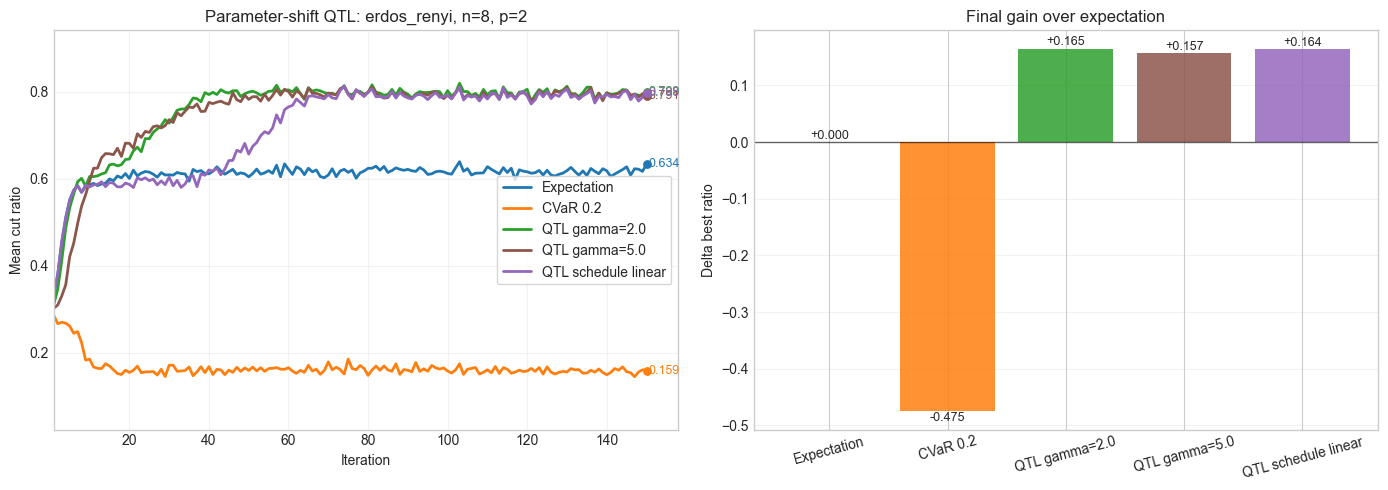

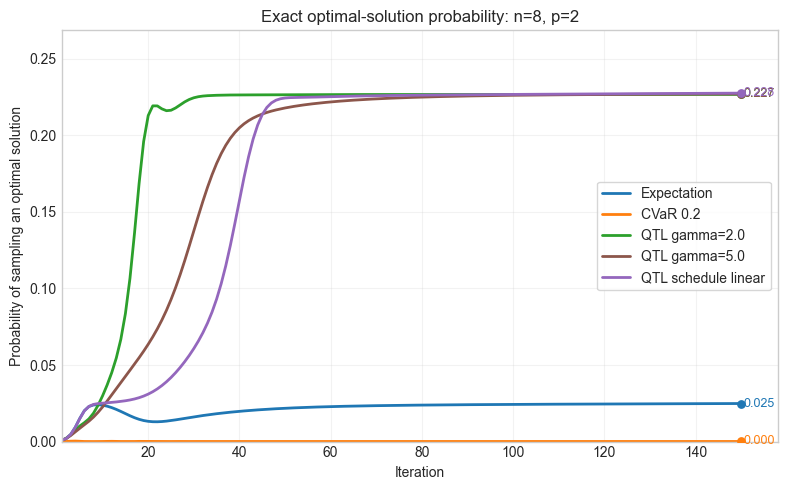

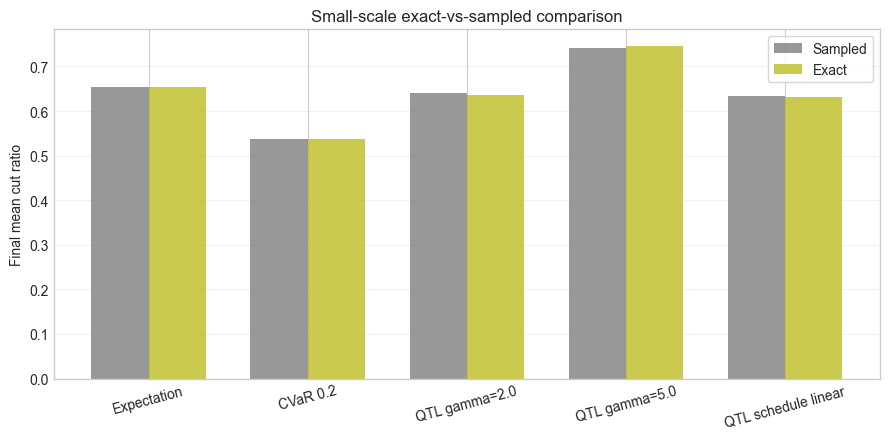

In [128]:
fig, axes = plt.subplots(1, len(BENCHMARK_CONFIG["depths"]) + 1, figsize=(9 * len(BENCHMARK_CONFIG["depths"]) + 5, 5))
if len(BENCHMARK_CONFIG["depths"]) == 1:
    curve_axes = [axes[0]]
    gain_ax = axes[1]
else:
    curve_axes = axes[:-1]
    gain_ax = axes[-1]

for ax, p in zip(curve_axes, BENCHMARK_CONFIG["depths"]):
    sub = fig1_df[fig1_df["p"] == p]
    plotted = []
    for name in CURVE_OBJECTIVES:
        agg = plot_mean_with_band(
            ax,
            sub[sub["objective"] == name],
            "iteration",
            CURVE_METRIC,
            name,
            OBJECTIVE_COLORS[name],
        )
        plotted.append((name, agg))
        ax.text(
            agg["iteration"].iloc[-1] + 0.6,
            agg["mean"].iloc[-1],
            f"{agg['mean'].iloc[-1]:.3f}",
            color=OBJECTIVE_COLORS[name],
            va="center",
            fontsize=9,
        )
    y_min = min(agg["mean"].min() for _, agg in plotted)
    y_max = max(agg["mean"].max() for _, agg in plotted)
    pad = max(0.004, 0.18 * (y_max - y_min))
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_xlim(1, BENCHMARK_CONFIG["steps"] + 8)
    ax.set_title(f"Parameter-shift QTL: {BENCHMARK_CONFIG['graph_families'][0]}, n={BENCHMARK_CONFIG['sizes'][0]}, p={p}")
    ax.locator_params(axis="x", integer=True)
    ax.set_xlabel("Iteration")
    ax.set_ylabel(CURVE_METRIC_LABEL)
    ax.grid(alpha=0.25)

curve_axes[0].legend(frameon=True)

gain_series = finite_summary.loc[CURVE_OBJECTIVES, GAIN_METRIC] - finite_summary.loc["Expectation", GAIN_METRIC]
gain_ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
bars = gain_ax.bar(
    gain_series.index,
    gain_series.values,
    color=[OBJECTIVE_COLORS[name] for name in gain_series.index],
    alpha=0.85,
)
for bar, value in zip(bars, gain_series.values):
    gain_ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + (0.0008 if value >= 0 else -0.0008),
        f"{value:+.3f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=9,
    )
gain_ax.set_title("Final gain over expectation")
gain_ax.set_ylabel("Delta best ratio")
gain_ax.tick_params(axis="x", rotation=15)
gain_ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

fig, opt_axes = plt.subplots(1, len(BENCHMARK_CONFIG["depths"]), figsize=(8 * len(BENCHMARK_CONFIG["depths"]), 5), sharey=True)
if len(BENCHMARK_CONFIG["depths"]) == 1:
    opt_axes = [opt_axes]

for ax, p in zip(opt_axes, BENCHMARK_CONFIG["depths"]):
    sub = fig1_exact_df[fig1_exact_df["p"] == p]
    plotted = []
    for name in CURVE_OBJECTIVES:
        agg = plot_mean_with_band(
            ax,
            sub[sub["objective"] == name],
            "iteration",
            "optimal_mass",
            name,
            OBJECTIVE_COLORS[name],
        )
        plotted.append((name, agg))
        ax.text(
            agg["iteration"].iloc[-1] + 0.6,
            agg["mean"].iloc[-1],
            f"{agg['mean'].iloc[-1]:.3f}",
            color=OBJECTIVE_COLORS[name],
            va="center",
            fontsize=9,
        )
    y_min = min(agg["mean"].min() for _, agg in plotted)
    y_max = max(agg["mean"].max() for _, agg in plotted)
    pad = max(0.002, 0.18 * (y_max - y_min + 1e-6))
    ax.set_ylim(max(0.0, y_min - pad), min(1.0, y_max + pad))
    ax.set_xlim(1, BENCHMARK_CONFIG["steps"] + 8)
    ax.set_title(f"Exact optimal-solution probability: n={BENCHMARK_CONFIG['sizes'][0]}, p={p}")
    ax.locator_params(axis="x", integer=True)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Probability of sampling an optimal solution")
    ax.grid(alpha=0.25)

opt_axes[0].legend(frameon=True)
plt.tight_layout()
plt.show()

exact_plot_df = exact_comparison_df.loc[CURVE_OBJECTIVES, ["sampled_mean_ratio", "exact_mean_ratio"]]
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(exact_plot_df.index))
width = 0.36
ax.bar(x - width / 2, exact_plot_df["sampled_mean_ratio"], width=width, label="Sampled", color="#7f7f7f", alpha=0.8)
ax.bar(x + width / 2, exact_plot_df["exact_mean_ratio"], width=width, label="Exact", color="#bcbd22", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(exact_plot_df.index, rotation=15)
ax.set_ylabel("Final mean cut ratio")
ax.set_title("Small-scale exact-vs-sampled comparison")
ax.legend(frameon=True)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
